# Machine Learning Classification

## Step 1: Library Import and Data Loading

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score
)
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# data loading
df = pd.read_csv('../data/processed_data.csv')
print(f"Loaded: {df.shape[0]} subjects, {df.shape[1]} columns")

Loaded: 1236 subjects, 208 columns


## Step 2: Adding Normalized Values to Dataset

In [2]:
volume_regions = [
    'Left_Thalamus', 'Right_Thalamus', 'Left_Putamen', 'Right_Putamen',
    'Left_Caudate', 'Right_Caudate', 'Left_Pallidum', 'Right_Pallidum',
    'Brain_Stem', 'Left_VentralDC', 'Right_VentralDC',
    'Left_Hippocampus', 'Right_Hippocampus', 'Left_Amygdala',
    'Left_Cerebellum_Cortex', 'Right_Cerebellum_Cortex',
    'Left_Cerebellum_White_Matter', 'Right_Cerebellum_White_Matter',
    'Left_Lateral_Ventricle', 'Right_Lateral_Ventricle'
]
for r in volume_regions:
    if r in df.columns:
        df[r + '_norm'] = df[r] / df['EstimatedTotalIntraCranialVol']

sa_lh = [c for c in df.columns if c.startswith('lh_') and c.endswith('_sa')]
sa_rh = [c for c in df.columns if c.startswith('rh_') and c.endswith('_sa')]
for col in sa_lh:
    df[col + '_norm'] = df[col] / df['lh_WhiteSurfArea']
for col in sa_rh:
    df[col + '_norm'] = df[col] / df['rh_WhiteSurfArea']

print(f"Dataset after normalization: {df.shape[1]} columns")

Dataset after normalization: 296 columns


## Step 3: Feature Selection

In [3]:
selected_features = [
    # demographics (1)
    'ENROLL_AGE',

    # global brain measures (5)
    'BrainSegVol_to_eTIV', 'TotalGrayVol', 'CortexVol', 'CerebralWhiteMatterVol', 'CSF',

    # subcortical structures (normalized) (8)
    'Left_Thalamus_norm', 'Right_Thalamus_norm',
    'Left_Putamen_norm', 'Right_Putamen_norm',
    'Left_Caudate_norm', 'Right_Caudate_norm',
    'Left_Pallidum_norm', 'Right_Pallidum_norm',

    # limbic system (3)
    'Left_Hippocampus_norm', 'Right_Hippocampus_norm', 'Left_Amygdala_norm',

    # brainstem and deep structures (3)
    'Brain_Stem_norm', 'Left_VentralDC_norm', 'Right_VentralDC_norm',

    # cerebellum (4)
    'Left_Cerebellum_Cortex_norm', 'Right_Cerebellum_Cortex_norm',
    'Left_Cerebellum_White_Matter_norm', 'Right_Cerebellum_White_Matter_norm',

    # ventricles (5)
    'Left_Lateral_Ventricle_norm', 'Right_Lateral_Ventricle_norm',
    'Left_Inf_Lat_Vent', 'Right_Inf_Lat_Vent', '3rd_Ventricle',

    # other subcortical structures (1)
    'Optic_Chiasm',

    # white matter / corpus callosum (7)
    'CC_Anterior', 'CC_Central', 'CC_Mid_Anterior', 'CC_Mid_Posterior', 'CC_Posterior',
    'WM_hypointensities', 'rhCortexVol',

    # cortical thickness (CTH) features (15)
    'lh_middletemporal_cth', 'rh_middletemporal_cth',
    'lh_parahippocampal_cth', 'rh_parahippocampal_cth',
    'rh_fusiform_cth', 'lh_inferiortemporal_cth', 'rh_inferiortemporal_cth',
    'lh_parsorbitalis_cth', 'rh_parsorbitalis_cth', 'rh_superiorfrontal_cth',
    'rh_medialorbitofrontal_cth', 'lh_lateralorbitofrontal_cth', 'rh_lateralorbitofrontal_cth',
    'rh_posteriorcingulate_cth', 'rh_isthmuscingulate_cth',

    # surface area (normalized) features (28)
    'lh_insula_sa_norm', 'rh_insula_sa_norm',
    'lh_precentral_sa_norm', 'rh_precentral_sa_norm',
    'lh_postcentral_sa_norm', 'rh_postcentral_sa_norm',
    'lh_paracentral_sa_norm', 'rh_paracentral_sa_norm',
    'lh_middletemporal_sa_norm', 'rh_middletemporal_sa_norm',
    'lh_superiortemporal_sa_norm', 'rh_superiortemporal_sa_norm',
    'lh_inferiortemporal_sa_norm', 'rh_inferiortemporal_sa_norm',
    'lh_temporalpole_sa_norm', 'rh_temporalpole_sa_norm',
    'rh_entorhinal_sa_norm', 'lh_entorhinal_sa_norm',
    'lh_superiorfrontal_sa_norm', 'rh_superiorfrontal_sa_norm',
    'lh_rostralmiddlefrontal_sa_norm', 'rh_rostralmiddlefrontal_sa_norm',
    'lh_caudalmiddlefrontal_sa_norm',
    'lh_parsorbitalis_sa_norm', 'rh_parsorbitalis_sa_norm',
    'lh_medialorbitofrontal_sa_norm', 'rh_medialorbitofrontal_sa_norm',
    'rh_inferiorparietal_sa_norm',
]

existing = [f for f in selected_features if f in df.columns]
missing = [f for f in selected_features if f not in df.columns]

print(f"Features found: {len(existing)}")
if missing:
    print(f"Missing ({len(missing)}):")
    for f in missing:
        print(f"  ❌ {f}")

X = df[existing].copy()
y = df['target'].copy()

print(f"\nFinal X: {X.shape}")
print(f"Distribution y:\n{y.value_counts()}")

Features found: 80

Final X: (1236, 80)
Distribution y:
target
2    571
1    538
0    127
Name: count, dtype: int64


## Step 4: Train and Test Sets + Scaling

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(f"Train set: {X_train_scaled.shape}")
print(f"Test set:    {X_test_scaled.shape}")

Train set: (927, 80)
Test set:    (309, 80)


## Step 5: Stratified K-Fold Cross-Validation

In [5]:
def run_stratified_cv(model, X, y, n_splits=5, model_name="Model"):
    # define stratified k-fold cross-validation
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # convert pandas objects to numpy arrays if needed
    X_array = X.values if hasattr(X, "values") else X
    y_array = y.values if hasattr(y, "values") else y

    # store metrics across folds
    fold_accuracies = []
    fold_macro_f1_scores = []
    fold_class_f1_scores = []

    # iterate through each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_array, y_array), 1):

        # split data into training and test sets
        X_train, X_test = X_array[train_idx], X_array[test_idx]
        y_train, y_test = y_array[train_idx], y_array[test_idx]

        # standardize features (fit only on training data)
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # train model
        model.fit(X_train, y_train)

        # predict test set
        y_pred = model.predict(X_test)

        # compute metrics
        accuracy = accuracy_score(y_test, y_pred)
        macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
        class_f1 = f1_score(y_test, y_pred, average=None, labels=[0, 1, 2], zero_division=0)

        # store fold results
        fold_accuracies.append(accuracy)
        fold_macro_f1_scores.append(macro_f1)
        fold_class_f1_scores.append(class_f1)

        # print fold results
        print(
            f"  Fold {fold}: Acc={accuracy:.3f}  MacroF1={macro_f1:.3f}  "
            f"[HC={class_f1[0]:.3f}, PD={class_f1[1]:.3f}, Prodromal={class_f1[2]:.3f}]"
        )

    # convert to numpy array for easier aggregation
    class_f1_array = np.array(fold_class_f1_scores)

    # print summary statistics
    print(f"  Accuracy   : {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f}")
    print(f"  Macro F1   : {np.mean(fold_macro_f1_scores):.3f} ± {np.std(fold_macro_f1_scores):.3f}")
    print(f"  F1 HC      : {np.mean(class_f1_array[:,0]):.3f} ± {np.std(class_f1_array[:,0]):.3f}")
    print(f"  F1 PD      : {np.mean(class_f1_array[:,1]):.3f} ± {np.std(class_f1_array[:,1]):.3f}")
    print(f"  F1 Prodrom : {np.mean(class_f1_array[:,2]):.3f} ± {np.std(class_f1_array[:,2]):.3f}")

    # return results for later analysis
    return {
        "name": model_name,
        "accuracies": fold_accuracies,
        "macro_f1_scores": fold_macro_f1_scores,
        "class_f1_scores": class_f1_array
    }

    # define models for cross-validation comparison
models_cv = [
    ("Random Forest", RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_split=5,
        class_weight="balanced_subsample", random_state=42
    )),

    ("SVM", SVC(
        kernel="rbf", class_weight="balanced",
        probability=True, random_state=42
    )),

    ("XGBoost", XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        objective="multi:softmax", num_class=3,
        eval_metric="mlogloss",
        random_state=42
    )),

    ("Logistic Regression", LogisticRegression(
        class_weight="balanced", max_iter=1000,
        solver="lbfgs", random_state=42
    )),
]

# store cross-validation results
cv_results = []

# run CV for each model
for model_name, model in models_cv:

    # print separator for readability
    print("=" * 55 + f"  {model_name}  " + "=" * 55)

    # run stratified cross-validation
    result = run_stratified_cv(model, X, y, n_splits=5, model_name=model_name)

    cv_results.append(result)

=======================================================  Random Forest  =======================================================
  Fold 1: Acc=0.573  MacroF1=0.400  [HC=0.000, PD=0.559, Prodromal=0.643]
  Fold 2: Acc=0.498  MacroF1=0.347  [HC=0.000, PD=0.472, Prodromal=0.568]
  Fold 3: Acc=0.522  MacroF1=0.357  [HC=0.000, PD=0.456, Prodromal=0.616]
  Fold 4: Acc=0.522  MacroF1=0.366  [HC=0.000, PD=0.507, Prodromal=0.590]
  Fold 5: Acc=0.563  MacroF1=0.395  [HC=0.000, PD=0.545, Prodromal=0.640]
  Accuracy   : 0.536 ± 0.028
  Macro F1   : 0.373 ± 0.021
  F1 HC      : 0.000 ± 0.000
  F1 PD      : 0.508 ± 0.040
  F1 Prodrom : 0.611 ± 0.029
=======================================================  SVM  =======================================================
  Fold 1: Acc=0.496  MacroF1=0.424  [HC=0.197, PD=0.536, Prodromal=0.540]
  Fold 2: Acc=0.522  MacroF1=0.437  [HC=0.196, PD=0.519, Prodromal=0.597]
  Fold 3: Acc=0.559  MacroF1=0.464  [HC=0.204, PD=0.546, Prodromal=0.642]
  Fold 4: Acc=0.5

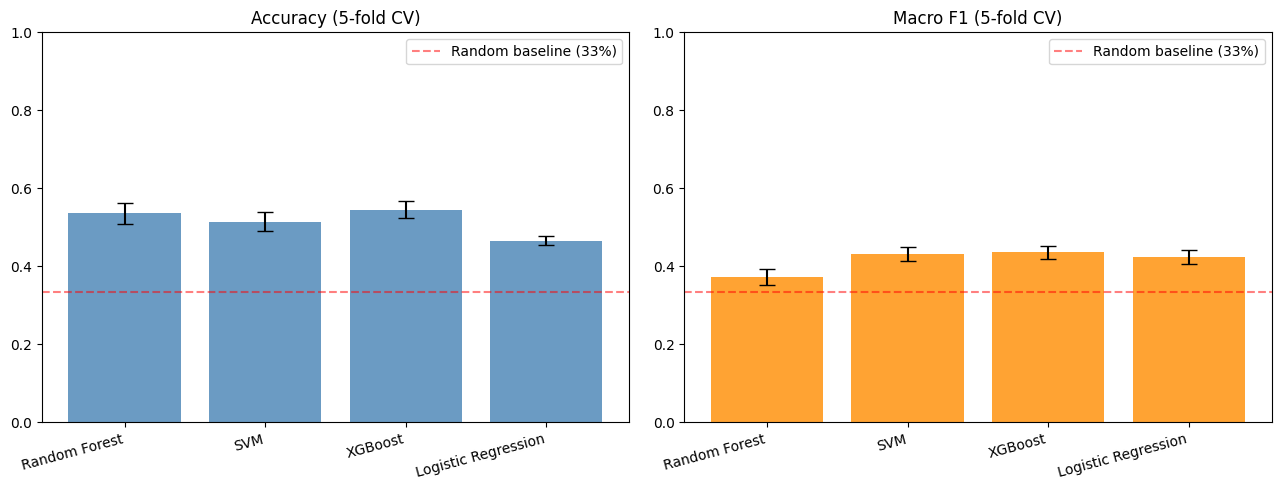

Model                       Accuracy      Macro F1    F1 HC    F1 PD  F1 Prod
──────────────────────────────────────────────────────────────────────────────
Random Forest          0.536±0.028  0.373±0.021  0.000   0.508   0.611
SVM                    0.515±0.024  0.432±0.018  0.185   0.524   0.588
XGBoost                0.545±0.022  0.436±0.016  0.175   0.523   0.608
Logistic Regression    0.466±0.012  0.423±0.018  0.253   0.471   0.546


In [6]:
# compare model performance: Accuracy vs Macro F1
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# extract model names
model_names = [r["name"] for r in cv_results]

# compute mean and standard deviation for accuracy
mean_accuracy = [np.mean(r["accuracies"]) for r in cv_results]
std_accuracy  = [np.std(r["accuracies"])  for r in cv_results]

# compute mean and standard deviation for macro F1
mean_macro_f1 = [np.mean(r["macro_f1_scores"]) for r in cv_results]
std_macro_f1  = [np.std(r["macro_f1_scores"])  for r in cv_results]

# x positions for bar plot
x = np.arange(len(model_names))

# plot both metrics side by side
for ax, means, stds, title, color in zip(
    axes,
    [mean_accuracy, mean_macro_f1],
    [std_accuracy, std_macro_f1],
    ["Accuracy (5-fold CV)", "Macro F1 (5-fold CV)"],
    ["steelblue", "darkorange"]
):
    # bar plot with error bars (std)
    ax.bar(x, means, yerr=stds, capsize=6, color=color, alpha=0.8)

    # set x-axis labels
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha="right")

    # set title
    ax.set_title(title)

    # fix y-axis range
    ax.set_ylim(0, 1)

    # baseline for random classifier (3 classes → ~0.33)
    ax.axhline(1/3, color="red", linestyle="--", alpha=0.5, label="Random baseline (33%)")

    ax.legend()

plt.tight_layout()
plt.show()

# print summary comparison table
print(f"{'Model':<22} {'Accuracy':>13} {'Macro F1':>13} {'F1 HC':>8} {'F1 PD':>8} {'F1 Prod':>8}")
print("─" * 78)

for r in cv_results:
    fpc = r["class_f1_scores"]

    print(
        f"{r['name']:<22} "
        f"{np.mean(r['accuracies']):.3f}±{np.std(r['accuracies']):.3f}  "
        f"{np.mean(r['macro_f1_scores']):.3f}±{np.std(r['macro_f1_scores']):.3f}  "
        f"{np.mean(fpc[:,0]):.3f}   "
        f"{np.mean(fpc[:,1]):.3f}   "
        f"{np.mean(fpc[:,2]):.3f}"
    )

## Step 6: Random Forest

In [7]:
# define custom class weights to handle class imbalance
# higher weight = stronger penalty for misclassification
class_weights = {0: 3.24, 1: 0.77, 2: 0.72}

# initialize Random Forest classifier with tuned hyperparameters
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight=class_weights,  # apply custom class weighting
    random_state=42
)

# train model on scaled training data
rf_model.fit(X_train_scaled, y_train)

# make predictions on test set
y_pred_rf = rf_model.predict(X_test_scaled)

# evaluate model performance
print("--- Random Forest Results ---")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=['HC (0)', 'PD (1)', 'Prodromal (2)']
    )
)

--- Random Forest Results ---
               precision    recall  f1-score   support

       HC (0)       0.00      0.00      0.00        32
       PD (1)       0.49      0.43      0.46       134
Prodromal (2)       0.52      0.69      0.60       143

     accuracy                           0.51       309
    macro avg       0.34      0.38      0.35       309
 weighted avg       0.45      0.51      0.47       309



## Step 7: SVM

In [8]:
# define custom class weights to handle class imbalance
# higher weight increases penalty for misclassification of that class
class_weights = {0: 3.24, 1: 0.77, 2: 0.72}

# initialize Support Vector Machine (RBF kernel)
svm_model = SVC(
    kernel='rbf',
    class_weight=class_weights,  # apply class weighting
    probability=True,            # enable probability estimates
    random_state=42
)

# train model on scaled training data
svm_model.fit(X_train_scaled, y_train)

# predict test labels
y_pred_svm = svm_model.predict(X_test_scaled)

# evaluate model performance
print("--- SVM Results ---")
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=['HC (0)', 'PD (1)', 'Prodromal (2)']
    )
)

--- SVM Results ---
               precision    recall  f1-score   support

       HC (0)       0.14      0.22      0.17        32
       PD (1)       0.57      0.51      0.54       134
Prodromal (2)       0.60      0.58      0.59       143

     accuracy                           0.51       309
    macro avg       0.44      0.44      0.43       309
 weighted avg       0.54      0.51      0.53       309



## Step 8: XGBClassifier

In [9]:
# define class weights to handle class imbalance
class_weights = {0: 3.24, 1: 0.77, 2: 0.72}

# compute sample weights for each training instance based on class labels
sample_weights_train = compute_sample_weight(class_weight=class_weights, y=y_train)

# initialize XGBoost classifier for multi-class classification
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    objective='multi:softmax',  # direct class prediction
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    use_label_encoder=False
)

# train model with sample weights to handle class imbalance
xgb_model.fit(
    X_train_scaled,
    y_train,
    sample_weight=sample_weights_train
)

# predict test set labels
y_pred_xgb = xgb_model.predict(X_test_scaled)

# evaluate model performance
print("--- XGBoost Results ---")
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=['HC (0)', 'PD (1)', 'Prodromal (2)']
    )
)

--- XGBoost Results ---
               precision    recall  f1-score   support

       HC (0)       0.27      0.09      0.14        32
       PD (1)       0.54      0.57      0.55       134
Prodromal (2)       0.56      0.62      0.59       143

     accuracy                           0.54       309
    macro avg       0.46      0.43      0.43       309
 weighted avg       0.52      0.54      0.53       309



## Step 9: Logistic Regression

In [10]:
# define class weights to handle class imbalance
class_weights = {0: 3.24, 1: 0.77, 2: 0.72}

# initialize Logistic Regression model
lr_model = LogisticRegression(
    class_weight=class_weights,
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)

# train model on scaled training data
lr_model.fit(X_train_scaled, y_train)

# predict test labels
y_pred_lr = lr_model.predict(X_test_scaled)

# evaluate model performance
print("--- Logistic Regression Results ---")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=['HC (0)', 'PD (1)', 'Prodromal (2)']
    )
)

--- Logistic Regression Results ---
               precision    recall  f1-score   support

       HC (0)       0.19      0.47      0.27        32
       PD (1)       0.62      0.47      0.53       134
Prodromal (2)       0.63      0.57      0.60       143

     accuracy                           0.51       309
    macro avg       0.48      0.50      0.47       309
 weighted avg       0.58      0.51      0.54       309



## Step 10: Comparison - Confusion Matrix

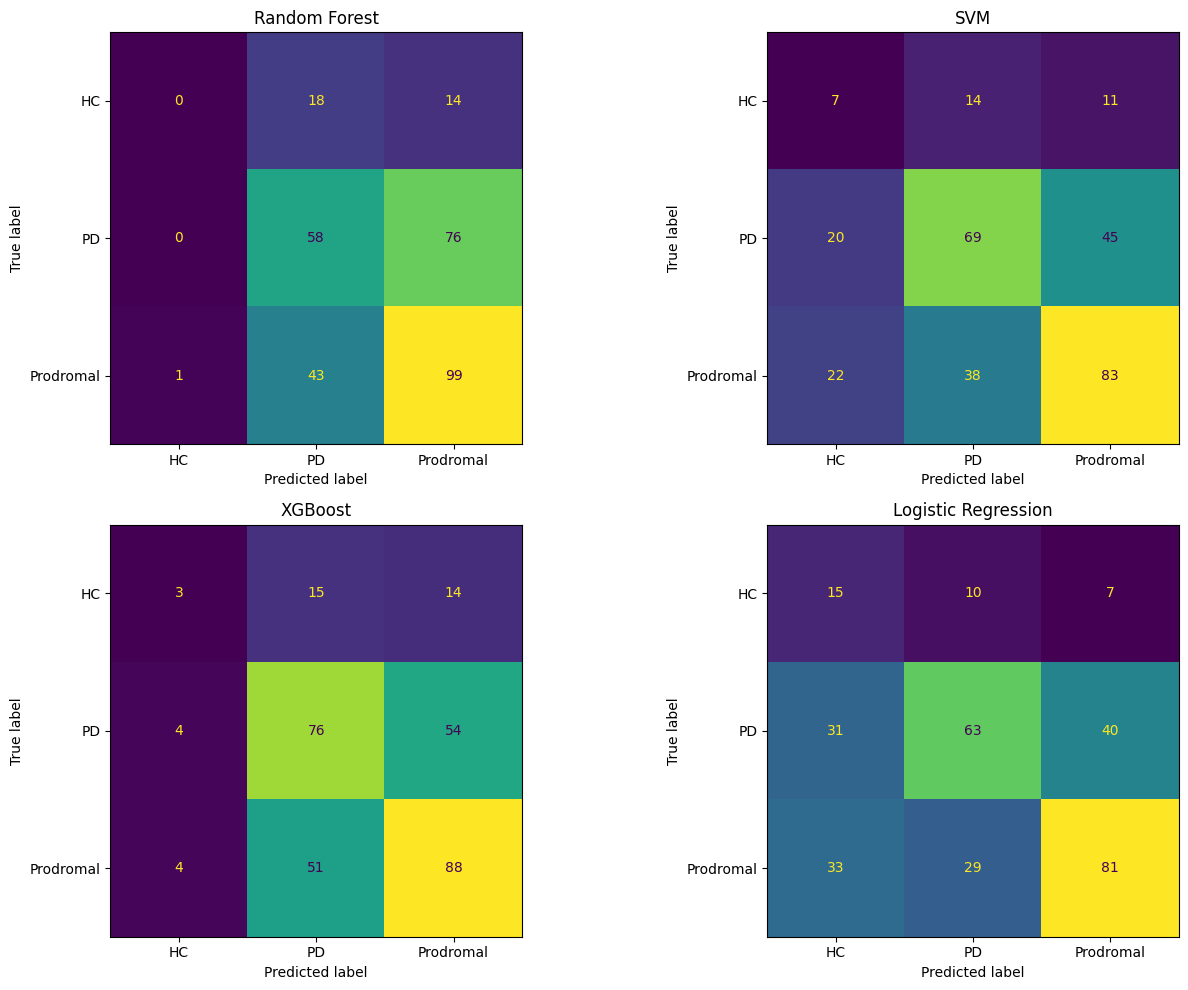

In [11]:
# create a 2x2 grid of subplots for confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# class labels for display in confusion matrices
labels = ['HC', 'PD', 'Prodromal']

# iterate over axes, model predictions, and titles
for ax, y_pred, title in zip(
    axes.flatten(),
    [y_pred_rf, y_pred_svm, y_pred_xgb, y_pred_lr],
    ['Random Forest', 'SVM', 'XGBoost', 'Logistic Regression']
):
    # compute confusion matrix for current model
    cm = confusion_matrix(y_test, y_pred)

    # create confusion matrix display object
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

    # plot confusion matrix on the given subplot
    disp.plot(ax=ax, colorbar=False)

    # set subplot title
    ax.set_title(title)

# adjust layout to prevent overlap
plt.tight_layout()

# display all plots
plt.show()

### Test: Two-stage Classification Pipeline

In [12]:
# import SMOTE for handling class imbalance in training data
from imblearn.over_sampling import SMOTE

# Stage 1 classification task:
# binary problem: Healthy Controls (0) vs Disease (1 = PD or Prodromal)
y_stage1_train = (y_train > 0).astype(int)
y_stage1_test  = (y_test > 0).astype(int)

# apply SMOTE only on training set to balance classes
smote = SMOTE(random_state=42)
X_train_balanced, y_stage1_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_stage1_train
)

# initialize XGBoost binary classifier
model_stage1 = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)

# train model on SMOTE-balanced training data
model_stage1.fit(X_train_balanced, y_stage1_train_balanced)

# make predictions on test set
y_pred_stage1 = model_stage1.predict(X_test_scaled)

# evaluate Stage 1 performance
print("--- Stage 1: HC vs Disease ---")

# confusion matrix
print(confusion_matrix(y_stage1_test, y_pred_stage1))

# detailed classification report
print(
    classification_report(
        y_stage1_test,
        y_pred_stage1,
        target_names=['HC (0)', 'Disease (1)']
    )
)

--- Stage 1: HC vs Disease ---
[[  3  29]
 [ 13 264]]
              precision    recall  f1-score   support

      HC (0)       0.19      0.09      0.12        32
 Disease (1)       0.90      0.95      0.93       277

    accuracy                           0.86       309
   macro avg       0.54      0.52      0.53       309
weighted avg       0.83      0.86      0.84       309



In [13]:
# Stage 2 classification task:
# binary classification: Parkinson's Disease (PD) vs Prodromal

# create masks to keep only disease subjects (exclude healthy controls)
train_mask_stage2 = y_train > 0
test_mask_stage2  = y_test > 0

# filter training data for Stage 2
X_train_stage2 = X_train_scaled[train_mask_stage2]
y_train_stage2 = y_train[train_mask_stage2]  # original labels: 1 (PD), 2 (Prodromal)

# filter test data for Stage 2
X_test_stage2 = X_test_scaled[test_mask_stage2]
y_test_stage2 = y_test[test_mask_stage2]

# remap labels to binary classification:
# PD (1) -> 0, Prodromal (2) -> 1
y_train_stage2_binary = (y_train_stage2 == 2).astype(int)
y_test_stage2_binary  = (y_test_stage2 == 2).astype(int)

# initialize XGBoost classifier for binary classification
model_stage2 = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)

# train model on Stage 2 training subset
model_stage2.fit(X_train_stage2, y_train_stage2_binary)

# predict on Stage 2 test subset
y_pred_stage2 = model_stage2.predict(X_test_stage2)

# evaluate Stage 2 performance
print("--- Stage 2: PD vs Prodromal ---")

# confusion matrix
print(confusion_matrix(y_test_stage2_binary, y_pred_stage2))

# detailed classification report
print(
    classification_report(
        y_test_stage2_binary,
        y_pred_stage2,
        target_names=['PD (0)', 'Prodromal (1)']
    )
)

--- Stage 2: PD vs Prodromal ---
[[75 59]
 [45 98]]
               precision    recall  f1-score   support

       PD (0)       0.62      0.56      0.59       134
Prodromal (1)       0.62      0.69      0.65       143

     accuracy                           0.62       277
    macro avg       0.62      0.62      0.62       277
 weighted avg       0.62      0.62      0.62       277



### Test: Comparison: manual feature selection vs. FDR pipeline (5-fold stratified CV)

In [14]:
# feature selection + model comparison using cross-validated pipeline

from sklearn.feature_selection import SelectFdr, f_classif
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

# select all numeric feature columns and exclude metadata/labels
exclude_columns = [
    'target', 'PATNO', 'COHORT_DEFINITION', 'ENROLL_STATUS',
    'COHORT', 'EVENT_ID'
]

# keep only numeric feature columns
feature_columns = [
    c for c in df.columns
    if c not in exclude_columns
    and df[c].dtype in ['float64', 'float32', 'int64', 'int32']
]

# define input matrix and labels
X_all = df[feature_columns].values
y_all = df['target'].values

# print dataset shape info
print(f"Total features available: {X_all.shape[1]}")
print(f"Number of samples: {X_all.shape[0]}")

# stratified k-fold for fair evaluation
skf_fs = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# define models to compare with feature selection
models_pipeline = [
    ("XGBoost + FDR", XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        objective="multi:softmax", num_class=3,
        eval_metric="mlogloss", random_state=42,
        use_label_encoder=False
    )),

    ("SVM + FDR", SVC(
        kernel="rbf", class_weight="balanced",
        probability=True, random_state=42
    )),

    ("Random Forest + FDR", RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_split=5,
        class_weight="balanced_subsample", random_state=42
    )),
]

# store results
feature_selection_results = []

# evaluate each model in pipeline
for model_name, model in models_pipeline:

    # build pipeline: scaling → feature selection → model
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("selector", SelectFdr(f_classif, alpha=0.05)),
        ("model", model)
    ])

    fold_f1_scores = []
    fold_selected_features = []

    # cross-validation loop
    for train_idx, test_idx in skf_fs.split(X_all, y_all):

        # split data
        X_train, X_test = X_all[train_idx], X_all[test_idx]
        y_train, y_test = y_all[train_idx], y_all[test_idx]

        # train pipeline
        pipe.fit(X_train, y_train)

        # predictions
        y_pred = pipe.predict(X_test)

        # evaluate macro F1
        fold_f1_scores.append(
            f1_score(y_test, y_pred, average="macro", zero_division=0)
        )

        # number of selected features in this fold
        fold_selected_features.append(
            pipe.named_steps["selector"].get_support().sum()
        )

    # summarize results across folds
    mean_f1 = np.mean(fold_f1_scores)
    std_f1 = np.std(fold_f1_scores)
    mean_features = np.mean(fold_selected_features)

    # print model performance
    print(
        f"{model_name:<25}  Macro F1: {mean_f1:.3f} ± {std_f1:.3f}  "
        f"(avg selected features: {mean_features:.0f})"
    )

    # store results
    feature_selection_results.append({
        "name": model_name,
        "f1": mean_f1,
        "std": std_f1,
        "n_features": mean_features
    })

Total features available: 293
Number of samples: 1236
XGBoost + FDR              Macro F1: 0.404 ± 0.019  (avg selected features: 116)
SVM + FDR                  Macro F1: 0.427 ± 0.009  (avg selected features: 116)
Random Forest + FDR        Macro F1: 0.393 ± 0.030  (avg selected features: 116)


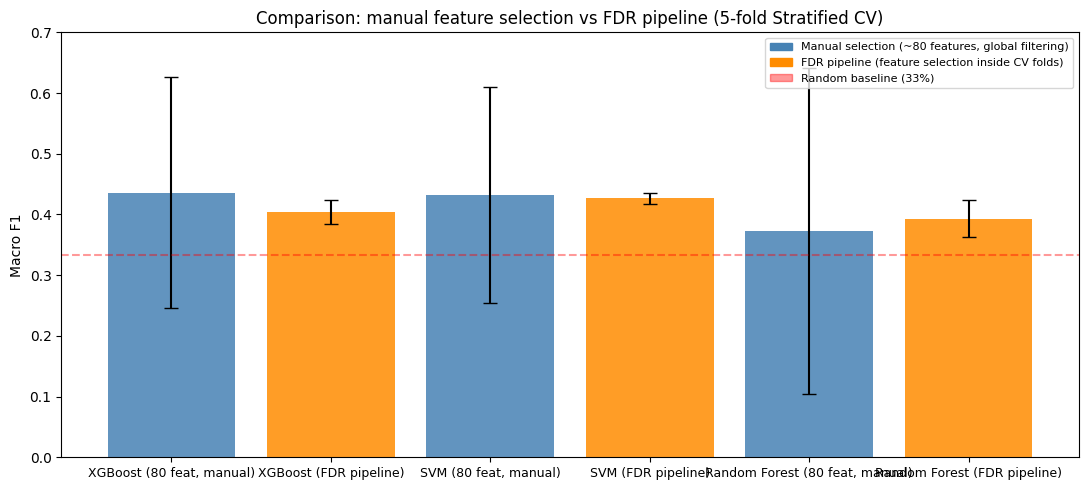

Conclusion:
  XGBoost + FDR: FDR pipeline is worse (-0.031)
  SVM + FDR: FDR pipeline is similar (-0.006)
  Random Forest + FDR: FDR pipeline is better (+0.020)


In [15]:
# comparison plot: manual feature selection vs FDR pipeline
fig, ax = plt.subplots(figsize=(11, 5))

# results from previous CV step (manual feature selection ~80 features)
manual_results = [
    ("XGBoost (80 feat, manual)", np.mean(cv_results[2]["class_f1_scores"]), np.std(cv_results[2]["class_f1_scores"])),
    ("SVM (80 feat, manual)", np.mean(cv_results[1]["class_f1_scores"]), np.std(cv_results[1]["class_f1_scores"])),
    ("Random Forest (80 feat, manual)", np.mean(cv_results[0]["class_f1_scores"]), np.std(cv_results[0]["class_f1_scores"])),
]

# results from FDR pipeline (cross-validated feature selection)
fdr_results = [
    (r["name"].replace(" + FDR", " (FDR pipeline)"), r["f1"], r["std"])
    for r in feature_selection_results
]

# interleave results for paired comparison (manual vs FDR)
labels, means, stds, colors = [], [], [], []
paired_results = list(zip(manual_results, fdr_results))

for (label1, mean1, std1), (label2, mean2, std2) in paired_results:
    labels += [label1, label2]
    means  += [mean1, mean2]
    stds   += [std1, std2]
    colors += ["steelblue", "darkorange"]

# x positions
x = np.arange(len(labels))

# bar plot with error bars
ax.bar(x, means, yerr=stds, capsize=5, color=colors, alpha=0.85)

# axis formatting
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 0.7)
ax.set_ylabel("Macro F1")
ax.set_title("Comparison: manual feature selection vs FDR pipeline (5-fold Stratified CV)")

# random baseline reference line (3 classes → ~0.33)
ax.axhline(1/3, color="red", linestyle="--", alpha=0.4, label="Random baseline (33%)")

# custom legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="steelblue", label="Manual selection (~80 features, global filtering)"),
    Patch(color="darkorange", label="FDR pipeline (feature selection inside CV folds)"),
    Patch(color="red", alpha=0.4, label="Random baseline (33%)")
], fontsize=8)

plt.tight_layout()
plt.show()

# textual conclusion based on performance difference
print("Conclusion:")
for (label, manual_mean, _), r in zip(manual_results, feature_selection_results):
    diff = r["f1"] - manual_mean

    if diff > 0.01:
        direction = "better"
    elif diff < -0.01:
        direction = "worse"
    else:
        direction = "similar"

    print(f"  {r['name']}: FDR pipeline is {direction} ({diff:+.3f})")